In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, MultipleLocator
plt.rcParams.update({
    'font.size': 7,             # Set global font size
    'font.family': 'Arial',      # Set global font family
    'legend.fontsize': 6,        # Set legend font size
    'figure.figsize': (5.5, 3.5), # Set figure size in inches
    'axes.formatter.limits': (-3, 6),
    'axes.formatter.use_mathtext': True,
})

import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 10000  # Increase the chunk size limit
mpl.rcParams['path.simplify'] = True
mpl.rcParams['path.simplify_threshold'] = 0.5  # Adjust this value if needed
from obspy.core import UTCDateTime

from scipy.stats import linregress
from sklearn.metrics import r2_score
import scipy.stats as stats

In [2]:
df1 = pd.read_csv("erosion.csv")
df1['Julday'] = df1['Date'].apply(lambda x: UTCDateTime(x).julday)
df1['Year'] = df1['Date'].apply(lambda x: UTCDateTime(x).year)
df1 = df1.drop([6, 14])
df1.reset_index(drop=True, inplace=True)
df1

,Date,Erosion1,Erosion2,Erosion3,CFS,Julday,Year
0,2019-06-21,-5.8157,-1.7500,NaN,3227.68,172,2019
1,2019-07-15,4.6391,0.3300,NaN,860.40,196,2019
2,2019-07-26,-19.8350,-1.6500,NaN,1915.65,207,2019
3,2019-08-11,-6.2511,-0.6900,NaN,2141.46,223,2019
4,2019-08-20,5.4366,-0.2800,NaN,1284.59,232,2019
5,2020-06-29,-3.0450,0.0600,-0.0573,1308.66,181,2020
6,2020-08-30,-10.8239,-6.6600,-6.3241,4768.94,243,2020
7,2021-06-05,-3.8230,-0.7100,2.8336,603.49,156,2021
8,2021-07-06,-6.7797,-1.4000,-0.5915,1736.22,187,2021
9,2021-07-16,5.9832,2.7000,-3.1235,4670.39,197,2021


In [6]:
df1['label'] = [f"{jd}-{str(year)[-2:]}" for jd, year in zip(df1['Julday'], df1['Year'])]

In [3]:
df2 = pd.read_csv("./output_images4/vol_estimates.csv", index_col=0)
df2 = df2.drop([0, 2, 3, 8, 9, 10, 13, 14, 15, 17, 18, 20, 25])
df2.reset_index(drop=True, inplace=True)
df2['Neg_Err_CIF'] = df2.CIF - df2.CIF_Lower
df2['Pos_Err_CIF'] = df2.CIF_Upper - df2.CIF
df2

,Year,Julian-Day,Volume,Estimated Volume Lower,Estimated Volume,Estimated Volume Upper,CIF,CIF_Lower,CIF_Upper,Uncertainty_Lower,Uncertainty_Upper,Estimated,Absolute_Error,Percent_Error,Neg_Err_CIF,Pos_Err_CIF
0,2019.0,172.0,83123.0,63991.0,74735.0,87209.0,4291.0,3794.0,4868.0,14.38,16.69,Yes,8388.0,10.09,497.0,577.0
1,2019.0,196.0,9869.0,3804.0,6939.0,10095.0,1155.0,1010.0,1301.0,45.18,45.48,Yes,2930.0,29.69,145.0,146.0
2,2019.0,207.0,29077.0,20782.0,25091.0,30813.0,2992.0,2693.0,3389.0,17.17,22.80,Yes,3986.0,13.71,299.0,397.0
3,2019.0,223.0,70705.0,45161.0,52944.0,60640.0,3283.0,2923.0,3639.0,14.70,14.54,No,17761.0,25.12,360.0,356.0
4,2019.0,232.0,21031.0,19348.0,23866.0,28233.0,1938.0,1729.0,2140.0,18.93,18.30,Yes,2835.0,13.48,209.0,202.0
5,2020.0,181.0,6612.0,6268.0,8719.0,11515.0,1856.0,1686.0,2050.0,28.11,32.07,Yes,2107.0,31.87,170.0,194.0
6,2020.0,243.0,95823.0,89025.0,100656.0,113433.0,5490.0,4952.0,6081.0,11.56,12.69,Yes,4833.0,5.04,538.0,591.0
7,2021.0,156.0,6127.0,7436.0,9944.0,14051.0,647.0,589.0,742.0,25.22,41.30,No,3817.0,62.30,58.0,95.0
8,2021.0,187.0,76906.0,60056.0,68531.0,77740.0,2002.0,1806.0,2215.0,12.37,13.44,Yes,8375.0,10.89,196.0,213.0
9,2021.0,197.0,80880.0,69323.0,77985.0,88016.0,6662.0,6061.0,7358.0,11.11,12.86,Yes,2895.0,3.58,601.0,696.0


In [7]:
# exclude 2023
# df1 = df1[df1.Year != 2023]
# df2 = df2[df2.Year != 2023]

# Support of erosion correlations with CIF

Target Line of Best Fit: Slope = 0.7098, Intercept = -62.1415


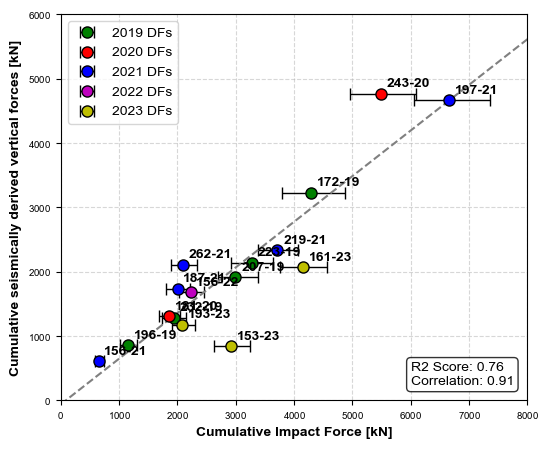

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))

for year, c in zip([2019, 2020, 2021, 2022, 2023], ['g', 'r', 'b', 'm', 'y']):
    temp1 = df1[df1.Year == year]
    temp2 = df2[df2.Year == year]
    ax.errorbar(
        x=temp2.CIF,
        y=temp1.CFS,
        xerr=temp2.loc[:,['Neg_Err_CIF', 'Pos_Err_CIF']].to_numpy().T,
        yerr=None,
        capsize=4,
        ls='none',
        elinewidth=1,
        color="k",
        mfc=c,
        marker="o",
        markersize=8,
        label=f"{year} DFs",
    )
for idx, row in df1.iterrows():
    ax.text(df2.loc[idx, 'CIF']+100, df1.loc[idx, 'CFS']+100, df1.loc[idx, 'label'], fontdict={"size": 10, "weight": "bold"})
    # ax.scatter(temp2.CIF, temp1.CFS, s=50, c = c, marker="o", edgecolors="k", alpha=0.8)
ax.set_xlim(0, 8000)
ax.set_ylim(0, 6000)
ax.set_xlabel("Cumulative Impact Force [kN]", fontsize=10, fontweight="bold")
ax.set_ylabel("Cumulative seismically derived vertical forces [kN]", fontsize=10, fontweight="bold")

target_slope, target_intercept, _, _, _ = linregress(df2.CIF, df1.CFS)
print(f"Target Line of Best Fit: Slope = {target_slope:.4f}, Intercept = {target_intercept:.4f}")
plot_x = np.linspace(0, 8000, 50)
ax.plot(plot_x, target_slope * plot_x + target_intercept, linestyle="--", color="grey", alpha=1)

cif_scaled = (df2.CIF - df2.CIF.min()) / (df2.CIF.max() - df2.CIF.min())
cfs_scaled = (df1.CFS - df1.CFS.min()) / (df1.CFS.max() - df1.CFS.min())
r2 = r2_score(cif_scaled, cfs_scaled)
corr, _ = stats.pearsonr(df2.CIF, df1.CFS)
info_text = f"R2 Score: {r2:.2f}\nCorrelation: {corr:.2f}"
ax.text(0.75, 0.1, info_text, transform=ax.transAxes, fontsize=10,
    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.legend(loc="best", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)
fig.tight_layout()
fig.savefig("output_images5/CFS-CIF_Corr_w2023.png", dpi=600)

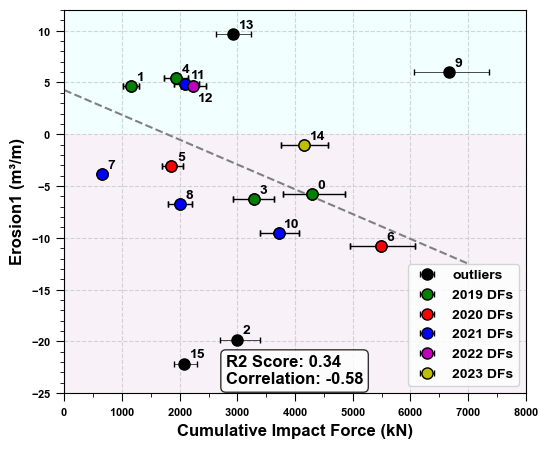

In [152]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))

ax.errorbar(
    x = df2.CIF,
    y = df1.Erosion1,
    xerr = df2.loc[:,['Neg_Err_CIF', 'Pos_Err_CIF']].to_numpy().T,
    yerr = None,
    capsize=2,
    ls='None',
    elinewidth=0.5,
    marker="o",
    color="k",
    markersize=8,
    label = "outliers",
)
for idx, row in df1.iterrows():
    if row.name == 12:
        ax.text(df2.loc[idx, 'CIF']+100, row.Erosion1-1.5, row.name, fontdict={"size": 10, "weight": "bold"})
    else:
        ax.text(df2.loc[idx, 'CIF']+100, row.Erosion1+0.5, row.name, fontdict={"size": 10, "weight": "bold"})

df11 = df1.drop([2, 9, 13, 15])
df21 = df2.drop([2, 9, 13, 15])

for year, c in zip([2019, 2020, 2021, 2022, 2023], ['g', 'r', 'b', 'm', "y"]):
    temp1 = df11[df11.Year == year]
    temp2 = df21[df21.Year == year]
    ax.errorbar(
        x=temp2.CIF,
        y=temp1.Erosion1,
        xerr=temp2.loc[:,['Neg_Err_CIF', 'Pos_Err_CIF']].to_numpy().T,
        yerr=None,
        capsize=2,
        ls='none',
        elinewidth=1,
        color="k",
        mfc=c,
        marker="o",
        markersize=8,
        label=f"{year} DFs",
    )
    
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.set_minor_locator(MultipleLocator(500))
ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.tick_params(axis='both', which='major', labelsize=8, length=6)
ax.tick_params(axis='both', which='minor', labelsize=7, length=3)
ax.set_xticks(range(0, 8000+1, 1000))
ax.set_yticks(range(-25, 10+1, 5))

ax.set_xlabel('Cumulative Impact Force (kN)', fontsize=12, fontweight="bold")
ax.set_ylabel('Erosion1 (m³/m)', fontsize=12, fontweight="bold")
ax.set_xlim(0, 8000)
ax.set_ylim(-25, 12)
ax.axhspan(0, 12, facecolor='cyan', alpha=0.05)
ax.axhspan(-25, 0, facecolor='purple', alpha=0.05)

corr, _ = stats.pearsonr(df21.CIF, df11.Erosion1)
r2 = corr ** 2
info_text = f"R2 Score: {r2:.2f}\nCorrelation: {corr:.2f}"
ax.text(0.35, 0.1, info_text, transform=ax.transAxes, fontsize=12,
    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

target_slope, target_intercept, _, _, _ = linregress(df21.CIF, df11.Erosion1)
plot_x = np.linspace(0, 7000, 50)
ax.plot(plot_x, target_slope * plot_x + target_intercept, linestyle="--", color="grey", alpha=1)

ax.legend(loc="best", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)
fig.tight_layout()
# fig.savefig("output_images5/Er1-CIF_w2023.png", dpi=600)

In [153]:
df1

,Date,Erosion1,Erosion2,Erosion3,CFS,Julday,Year
0,2019-06-21,-5.8157,-1.7500,NaN,3227.68,172,2019
1,2019-07-15,4.6391,0.3300,NaN,860.40,196,2019
2,2019-07-26,-19.8350,-1.6500,NaN,1915.65,207,2019
3,2019-08-11,-6.2511,-0.6900,NaN,2141.46,223,2019
4,2019-08-20,5.4366,-0.2800,NaN,1284.59,232,2019
5,2020-06-29,-3.0450,0.0600,-0.0573,1308.66,181,2020
6,2020-08-30,-10.8239,-6.6600,-6.3241,4768.94,243,2020
7,2021-06-05,-3.8230,-0.7100,2.8336,603.49,156,2021
8,2021-07-06,-6.7797,-1.4000,-0.5915,1736.22,187,2021
9,2021-07-16,5.9832,2.7000,-3.1235,4670.39,197,2021


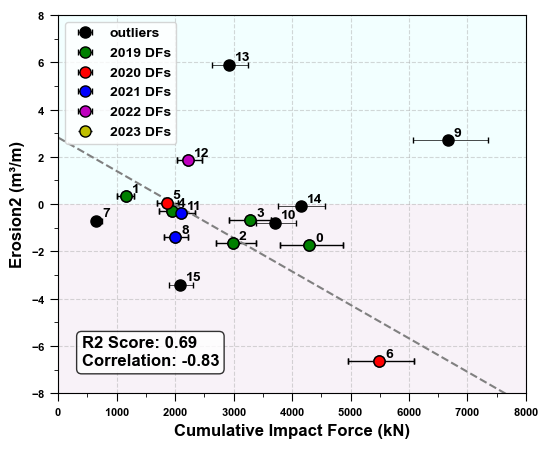

In [154]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))

ax.errorbar(
    x = df2.CIF,
    y = df1.Erosion2,
    xerr = df2.loc[:,['Neg_Err_CIF', 'Pos_Err_CIF']].to_numpy().T,
    yerr = None,
    capsize=2,
    ls='None',
    elinewidth=0.5,
    marker="o",
    color="k",
    markersize=8,
    label = "outliers",
)
for idx, row in df1.iterrows():
    ax.text(df2.loc[idx, 'CIF']+100, row.Erosion2 + 0.15, row.name, fontdict={"size": 10, "weight": "bold"})

df12 = df1.drop([7, 9, 10, 13, 14, 15])
df22 = df2.drop([7, 9, 10, 13, 14, 15])
  
for year, c in zip([2019, 2020, 2021, 2022, 2023], ['g', 'r', 'b', 'm', 'y']):
    temp1 = df12[df12.Year == year]
    temp2 = df22[df22.Year == year]
    ax.errorbar(
        x=temp2.CIF,
        y=temp1.Erosion2,
        xerr=temp2.loc[:,['Neg_Err_CIF', 'Pos_Err_CIF']].to_numpy().T,
        yerr=None,
        capsize=2,
        ls='none',
        elinewidth=1,
        color="k",
        mfc=c,
        marker="o",
        markersize=8,
        label=f"{year} DFs"
    )
    # for idx, row in temp1.iterrows():
    #     ax.text(temp2.loc[idx, 'CIF']+100, row.Erosion2 + 0.5, row.name, fontdict={"size": 10, "weight": "bold"})

ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.set_minor_locator(MultipleLocator(500))
ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(2))
ax.tick_params(axis='both', which='major', labelsize=8, length=6)
ax.tick_params(axis='both', which='minor', labelsize=7, length=3)
ax.set_xticks(range(0, 8000+1, 1000))
ax.set_yticks(range(-8, 8+1, 2))

ax.set_xlabel('Cumulative Impact Force (kN)', fontsize=12, fontweight="bold")
ax.set_ylabel('Erosion2 (m³/m)', fontsize=12, fontweight="bold")
ax.set_xlim(0, 8000)
ax.set_ylim(-8, 8)
ax.axhspan(0, 8, facecolor='cyan', alpha=0.05)
ax.axhspan(-8, 0, facecolor='purple', alpha=0.05)

corr, _ = stats.pearsonr(df22.CIF, df12.Erosion2)
r2 = corr ** 2
info_text = f"R2 Score: {r2:.2f}\nCorrelation: {corr:.2f}"
ax.text(0.05, 0.15, info_text, transform=ax.transAxes, fontsize=12,
    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

target_slope, target_intercept, _, _, _ = linregress(df22.CIF, df12.Erosion2)
plot_x = np.linspace(0, 8000, 50)
ax.plot(plot_x, target_slope * plot_x + target_intercept, linestyle="--", color="grey", alpha=1)

ax.legend(loc="best", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)
fig.tight_layout()
# fig.savefig("output_images5/Er2-CIF_w2023.png", dpi=600)

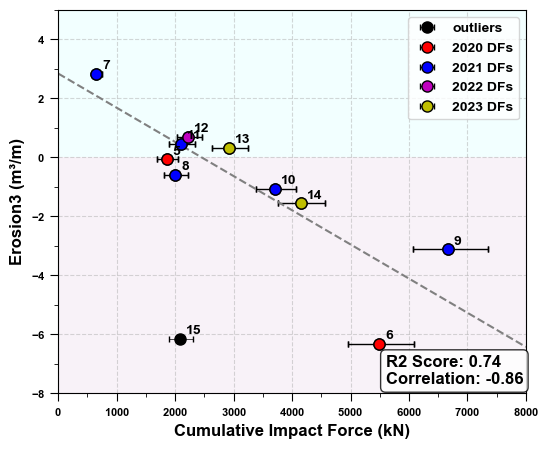

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))

ax.errorbar(
    x = df2.CIF,
    y = df1.Erosion3,
    xerr = df2.loc[:,['Neg_Err_CIF', 'Pos_Err_CIF']].to_numpy().T,
    yerr = None,
    capsize=2,
    ls='None',
    elinewidth=0.5,
    marker="o",
    color="k",
    markersize=8,
    label = "outliers",
)
for idx, row in df1.iterrows():
    ax.text(df2.loc[idx, 'CIF']+100, row.Erosion3+0.15, row.name, fontdict={"size": 10, "weight": "bold"})

df13 = df1.drop([0, 1, 2, 3, 4, 15])
df23 = df2.drop([0, 1, 2, 3, 4, 15])

for year, c in zip([2020, 2021, 2022, 2023], ['r', 'b', 'm', 'y']):
    temp1 = df13[df13.Year == year]
    temp2 = df23[df23.Year == year]
    ax.errorbar(
        x=temp2.CIF,
        y=temp1.Erosion3,
        xerr=temp2.loc[:,['Neg_Err_CIF', 'Pos_Err_CIF']].to_numpy().T,
        yerr=None,
        capsize=2,
        ls='none',
        elinewidth=1,
        color="k",
        mfc=c,
        marker="o",
        markersize=8,
        label=f"{year} DFs"
    )
    # for idx, row in temp1.iterrows():
    #     ax.text(temp2.loc[idx, 'CIF'], row.Erosion3, row.name, fontdict={"size": 8, "weight": "bold"})

ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.xaxis.set_minor_locator(MultipleLocator(500))
ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(2))
ax.tick_params(axis='both', which='major', labelsize=8, length=6)
ax.tick_params(axis='both', which='minor', labelsize=7, length=3)
ax.set_xticks(range(0, 8000+1, 1000))
ax.set_yticks(range(-8, 5+1, 2))

ax.set_xlabel('Cumulative Impact Force (kN)', fontsize=12, fontweight="bold")
ax.set_ylabel('Erosion3 (m³/m)', fontsize=12, fontweight="bold")
ax.set_xlim(0, 8000)
ax.set_ylim(-8, 5)
ax.axhspan(0, 5, facecolor='cyan', alpha=0.05)
ax.axhspan(-8, 0, facecolor='purple', alpha=0.05)

corr, _ = stats.pearsonr(df23.CIF, df13.Erosion3)
r2 = corr ** 2
info_text = f"R2 Score: {r2:.2f}\nCorrelation: {corr:.2f}"
ax.text(0.7, 0.1, info_text, transform=ax.transAxes, fontsize=12,
    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

target_slope, target_intercept, _, _, _ = linregress(df23.CIF, df13.Erosion3)
plot_x = np.linspace(0, 8000, 50)
ax.plot(plot_x, target_slope * plot_x + target_intercept, linestyle="--", color="grey", alpha=1)

ax.legend(loc="best", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)
fig.tight_layout()
fig.savefig("output_images5/Er3-CIF_w2023.png", dpi=600)

2019-06-21
2019-07-15
2019-07-26
2019-08-11
2019-08-20
2020-06-29
2020-08-30
2021-06-05
2021-07-06
2021-07-16
2021-08-07
2021-09-19
2022-06-05
2023-06-02
2023-06-10
2023-07-12


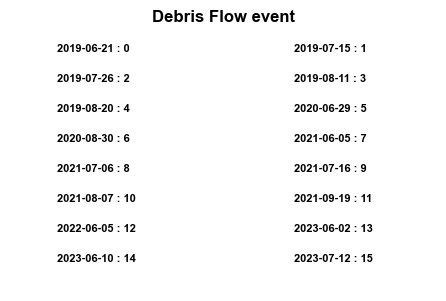

In [340]:
fig, ax = plt.subplots()

ax.set_ylim(-8, 10)
ax.set_xlim(-1.1, -0.2)

ax.text(-0.8, 10, "Debris Flow event", fontsize=12)
for i, x, y in zip(range(0,16), [-1, -0.5, -1, -0.5, -1, -0.5, -1, -0.5, -1, -0.5, -1, -0.5, -1, -0.5, -1, -0.5], [8]*2+[6]*2+[4]*2+[2]*2+[0]*2+[-2]*2+[-4]*2+[-6]*2+[-8]*2):
    print(df1.loc[i, ['Date']].item())
    ax.text(x, y, f"{df1.loc[i, ['Date']].item()} : {df1.loc[i].name}", fontsize=8)

ax.set_axis_off()
# fig.tight_layout()
fig.savefig("output_images5/event_map_w2023.png", dpi=600)

# xLSTM CIF Diff and Erosion realation

In [9]:
import numpy as np
import pandas as pd
from obspy import UTCDateTime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter, MultipleLocator

import seaborn as sns
from scipy.stats import linregress
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import scipy.stats as stats


from tqdm import tqdm

import sys
sys.path.append('../')
from functions.data_processing.read_data import load_label, load_label2
from functions.utils import *

In [10]:
def edit_ax(ax, lab):
    if lab == 1:
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.xaxis.set_minor_locator(MultipleLocator(100))
        ax.xaxis.set_major_locator(MultipleLocator(500))
        ax.yaxis.set_minor_locator(MultipleLocator(1))
        ax.yaxis.set_major_locator(MultipleLocator(5))
        ax.tick_params(axis='both', which='major', labelsize=8, length=6)
        ax.tick_params(axis='both', which='minor', labelsize=7, length=3)
        ax.set_xticks(range(0, 8000+1, 500))
        ax.set_yticks(range(-25, 10+1, 5))

        ax.set_xlabel('Cumulative Impact Force (kN)', fontsize=10,fontweight="bold")
        ax.set_ylabel('Local reach change (m³/m)', fontsize=10,fontweight="bold")
        ax.set_xlim(0, 8000)
        ax.set_ylim(-25, 12)
        ax.axhspan(0, 12, facecolor='green', alpha=0.05)
        ax.axhspan(-25, 0, facecolor='red', alpha=0.05)
    elif lab == 2:
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.xaxis.set_minor_locator(MultipleLocator(100))
        ax.xaxis.set_major_locator(MultipleLocator(500))
        ax.yaxis.set_minor_locator(MultipleLocator(1))
        ax.yaxis.set_major_locator(MultipleLocator(2))
        ax.tick_params(axis='both', which='major', labelsize=8, length=6)
        ax.tick_params(axis='both', which='minor', labelsize=7, length=3)
        ax.set_xticks(range(0, 8000+1, 500))
        ax.set_yticks(range(-8, 8+1, 2))

        ax.set_xlabel('Cumulative Impact Force (kN)', fontsize=10,fontweight="bold")
        ax.set_ylabel('Downstream reach change (m³/m)', fontsize=10,fontweight="bold")
        ax.set_xlim(0, 8000)
        ax.set_ylim(-8, 8)
        ax.axhspan(0, 8, facecolor='green', alpha=0.05)
        ax.axhspan(-8, 0, facecolor='red', alpha=0.05)
    elif lab == 3:
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
        ax.xaxis.set_minor_locator(MultipleLocator(100))
        ax.xaxis.set_major_locator(MultipleLocator(500))
        ax.yaxis.set_minor_locator(MultipleLocator(1))
        ax.yaxis.set_major_locator(MultipleLocator(2))
        ax.tick_params(axis='both', which='major', labelsize=8, length=6)
        ax.tick_params(axis='both', which='minor', labelsize=7, length=3)
        ax.set_xticks(range(0, 8000+1, 500))
        ax.set_yticks(range(-8, 5+1, 2))

        ax.set_xlabel('Cumulative Impact Force (kN)', fontsize=10,fontweight="bold")
        ax.set_ylabel('Long reach change (m³/m)', fontsize=10,fontweight="bold")
        ax.set_xlim(0, 8000)
        ax.set_ylim(-8, 5)
        ax.axhspan(0, 5, facecolor='green', alpha=0.05)
        ax.axhspan(-8, 0, facecolor='red', alpha=0.05)

    return None

In [ ]:
import json
with open("../config/event_id_map.json", "r") as f:
    event_id_map = json.load(f)
test_dir = "../model_test"
thres = 2

In [15]:
interval = 15
diff_list_2019 = []
results_2019_ILL11 = {}
results_2019_ILL12 = {}
prediction_csums_ILL11 = []
prediction_csums_ILL12 = []
year = 2019
juldays = [172, 196, 207, 223, 232]
julday_list_2019 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
for event_id, julday in zip(["3", "6", "7", "8", "9"], juldays):
    # julday = 172
    component = "EHZ"
    network = "9S"
    test_dir = "../model_test"
    model = "xLSTM"
    interval_seconds = interval
    # Load ILL12 data
    station = "ILL12"
    # st1 = load_seismic_data_test(julday= int(julday), station= station, year= year, component= component, network= network)
    df_dir = f"{test_dir}/{station}/{model}_{interval_seconds}/{year}/df"
    df1 = pd.read_csv(f"{df_dir}/{julday}.csv", index_col=False)
    # Load ILL11 data
    station = "ILL11"
    # st2 = load_seismic_data_test(julday= int(julday), station= station, year= year, component= component, network= network)
    df_dir = f"{test_dir}/{station}/{model}_{interval_seconds}/{year}/df"
    df2 = pd.read_csv(f"{df_dir}/{julday}.csv", index_col=False)

    df1['Timestamps'] = df1['Timestamps'].apply(lambda x: UTCDateTime(x))
    df2['Timestamps'] = df2['Timestamps'].apply(lambda x: UTCDateTime(x))
    df1 = df1[df1.Timestamps.between(UTCDateTime(event_id_map[event_id]['start_time']) - 3600, UTCDateTime(event_id_map[event_id]['end_time']) + 3600)]
    df2 = df2[df2.Timestamps.between(UTCDateTime(event_id_map[event_id]['start_time']) - 3600, UTCDateTime(event_id_map[event_id]['end_time']) + 3600)]
    temp = df2[df2['Predicted_Output_Mean'] > thres]
    prediction_csums_ILL11.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
    
    temp = df1[df1['Predicted_Output_Mean'] > thres]
    prediction_csums_ILL12.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
    
    csum1 = df1[df1["Predicted_Output_Mean"] > thres]['Predicted_Output_Mean'].sum()
    csum2 = df2[df2["Predicted_Output_Mean"] > thres]['Predicted_Output_Mean'].sum()
    diff = csum2 - csum1
    diff_list_2019.append(diff)

prediction_csums = np.array(prediction_csums_ILL11)
results_2019_ILL11[model] = prediction_csums
prediction_csums = np.array(prediction_csums_ILL12)
results_2019_ILL12[model] = prediction_csums

# 2020
year = 2020
juldays = [156, 160, 169, 181, 243]
start_times = ["2020-06-04 15:00:00", "2020-06-08 15:00:00", "2020-06-17 03:00:00", "2020-06-29 04:30:00", "2020-08-30 05:00:00"] # "2020-06-07 09:00:00"
end_times = ["2020-06-04 18:00:00", "2020-06-08 21:00:00", "2020-06-17 07:00:00", "2020-06-29 07:30:00", "2020-08-30 12:00:00"] # "2020-06-07 10:30:00"
julday_list_2020_11 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2020_ILL11 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        df = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2020_ILL11[model] = prediction_csums
year = 2020
juldays = [156, 160, 169, 181, 243]
start_times = ["2020-06-04 15:00:00", "2020-06-08 13:00:00", "2020-06-17 01:00:00", "2020-06-29 03:30:00", "2020-08-30 04:00:00"] # "2020-06-07 09:00:00"
end_times = ["2020-06-04 18:00:00", "2020-06-08 21:00:00", "2020-06-17 07:00:00", "2020-06-29 07:30:00", "2020-08-30 12:00:00"] # "2020-06-07 10:30:00"
julday_list_2020_12 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2020_ILL12 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        df = pd.read_csv(f"{test_dir}/ILL12/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2020_ILL12[model] = prediction_csums
# 2021
year = 2021
juldays = [131, 136, 142, 156, 173, 175, 187, 194, 197, 219, 262]
start_times = ["2021-05-11 13:30:00", "2021-05-16 15:30:00", "2021-05-21 22:00:00", "2021-06-05 09:00:00",
            "2021-06-22 19:00:00", "2021-06-24 14:30:00", "2021-07-06 18:00:00", "2021-07-13 15:00:00",
            "2021-07-16 03:00:00", "2021-08-07 13:30:00", "2021-09-19 05:30:00"]
end_times = ["2021-05-11 19:30:00", "2021-05-16 22:00:00", "2021-05-22 02:30:00", "2021-06-05 13:00:00",
            "2021-06-22 22:30:00", "2021-06-24 19:00:00", "2021-07-06 22:00:00", "2021-07-13 20:00:00",
            "2021-07-16 08:00:00", "2021-08-07 18:00:00", "2021-09-19 12:30:00"]
julday_list_2021_11 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2021_ILL11 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        if julday == 142:
            df1 = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday-1}.csv", index_col=False)
            df2 = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
            df = pd.concat([df1, df2], ignore_index=True)
        else:
            df = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2021_ILL11[model] = prediction_csums
year = 2021
juldays = [173, 175, 187, 194, 197, 262]
start_times = ["2021-06-22 19:00:00", "2021-06-24 14:30:00", "2021-07-06 18:00:00", "2021-07-13 15:00:00",
            "2021-07-16 03:00:00", "2021-09-19 05:30:00"]
end_times = ["2021-06-22 22:30:00", "2021-06-24 19:00:00", "2021-07-06 22:00:00", "2021-07-13 21:00:00",
            "2021-07-16 08:00:00", "2021-09-19 12:30:00"]
julday_list_2021_12 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2021_ILL12 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        if julday == 142:
            df1 = pd.read_csv(f"{test_dir}/ILL12/{model}_{interval}/{year}/df/{julday-1}.csv", index_col=False)
            df2 = pd.read_csv(f"{test_dir}/ILL12/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
            df = pd.concat([df1, df2], ignore_index=True)
        else:
            df = pd.read_csv(f"{test_dir}/ILL12/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2021_ILL12[model] = prediction_csums
# 2022
year = 2022
juldays = [156, 185]
start_times = ["2022-06-05 10:30:00", "2022-07-04 21:00:00"]
end_times = ["2022-06-05 13:30:00", "2022-07-04 23:59:59"]
julday_list_2022_11 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2022_ILL11 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        df = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2022_ILL11[model] = prediction_csums
year = 2022
juldays = [156, 185]
start_times = ["2022-06-05 10:30:00", "2022-07-04 21:00:00"]
end_times = ["2022-06-05 13:30:00", "2022-07-04 23:59:59"]
julday_list_2022_12 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2022_ILL12 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        df = pd.read_csv(f"{test_dir}/ILL12/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2022_ILL12[model] = prediction_csums
# 2023
year = 2023
juldays = [153, 161, 193]
start_times = ["2023-06-02 17:00:00", "2023-06-10 05:00:00", "2023-07-12 03:00:00"]
end_times = ["2023-06-02 21:30:00", "2023-06-10 09:30:00", "2023-07-12 06:00:00"]
julday_list_2023_11 = [f"{jd}-{str(year)[-2:]}" for jd in juldays]
results_2023_ILL11 = {}
for model in ['xLSTM']:
    prediction_csums = []
    i=0
    for julday, start_time, end_time in tqdm(zip(juldays, start_times, end_times), total=len(juldays)):
        df = pd.read_csv(f"{test_dir}/ILL11/{model}_{interval}/{year}/df/{julday}.csv", index_col=False)
        df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
        df = df[df['Timestamps'].between(UTCDateTime(start_time), UTCDateTime(end_time))]
        df.reset_index(drop=True, inplace=True)
        temp = df[df['Predicted_Output_Mean'] > thres]
        prediction_csums.append([temp['Predicted_Output_Mean'].sum(), temp['Predicted_Output_Min'].sum(), temp['Predicted_Output_Max'].sum()])
        i+=1
    prediction_csums = np.array(prediction_csums)
    results_2023_ILL11[model] = prediction_csums

100%|██████████| 3/3 [00:00<00:00,  3.54it/s]


In [16]:
diff_list_2020 = results_2020_ILL11['xLSTM'][:, 0] - results_2020_ILL12['xLSTM'][:, 0]
diff_list_2021 = results_2021_ILL11['xLSTM'][[4,5,6,7,8,10], 0] - results_2021_ILL12['xLSTM'][:, 0]
diff_list_2022 = results_2022_ILL11['xLSTM'][:, 0] - results_2022_ILL12['xLSTM'][:, 0]

In [17]:
df1 = pd.read_csv("erosion.csv")
df1['Julday'] = df1['Date'].apply(lambda x: UTCDateTime(x).julday)
df1['Year'] = df1['Date'].apply(lambda x: UTCDateTime(x).year)
df1 = df1.drop([6, 14])
df1.reset_index(drop=True, inplace=True)
df1

,Date,Erosion1,Erosion2,Erosion3,CFS,Julday,Year
0,2019-06-21,-5.8157,-1.7500,NaN,3227.68,172,2019
1,2019-07-15,4.6391,0.3300,NaN,860.40,196,2019
2,2019-07-26,-19.8350,-1.6500,NaN,1915.65,207,2019
3,2019-08-11,-6.2511,-0.6900,NaN,2141.46,223,2019
4,2019-08-20,5.4366,-0.2800,NaN,1284.59,232,2019
5,2020-06-29,-3.0450,0.0600,-0.0573,1308.66,181,2020
6,2020-08-30,-10.8239,-6.6600,-6.3241,4768.94,243,2020
7,2021-06-05,-3.8230,-0.7100,2.8336,603.49,156,2021
8,2021-07-06,-6.7797,-1.4000,-0.5915,1736.22,187,2021
9,2021-07-16,5.9832,2.7000,-3.1235,4670.39,197,2021


In [18]:
diff_2019 = results_2019_ILL11['xLSTM'] - results_2019_ILL12['xLSTM']
diff_2020 = results_2020_ILL11['xLSTM'] - results_2020_ILL12['xLSTM']
diff_2021 = results_2021_ILL11['xLSTM'][[4,5,6,7,8,10], :] - results_2021_ILL12['xLSTM']
diff_2022 = results_2022_ILL11['xLSTM'] - results_2022_ILL12['xLSTM']
diff_2019[:,1] = diff_2019[:,0] - diff_2019[:,1]
diff_2019[:,2] = diff_2019[:,2] - diff_2019[:,0]

diff_2020[:,1] = diff_2020[:,0] - diff_2020[:,1]
diff_2020[:,2] = diff_2020[:,2] - diff_2020[:,0]

diff_2021[:,1] = diff_2021[:,0] - diff_2021[:,1]
diff_2021[:,2] = diff_2021[:,2] - diff_2021[:,0]

diff_2022[:,1] = diff_2022[:,0] - diff_2022[:,1]
diff_2022[:,2] = diff_2022[:,2] - diff_2022[:,0]

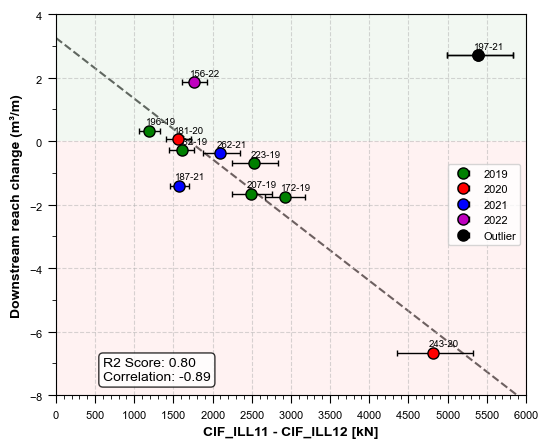

In [19]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))

x_2019, y_2019 = np.array(diff_list_2019), df1[df1.Year == 2019]['Erosion2'].values
x_2020, y_2020 = diff_list_2020[-2:], df1[df1.Year == 2020]['Erosion2'].values
x_2021, y_2021 = diff_list_2021[[2, 4, 5]], df1[df1.Year == 2021].iloc[[1, 2, 4]]['Erosion2'].values
x_2022, y_2022 = diff_list_2022[0:1], df1[df1.Year == 2022]['Erosion2'].values

ax.errorbar(
    x=diff_2019[:,0],
    y=y_2019,
    xerr=diff_2019[:,1:3].T,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="g",
    marker="o",
    markersize=8,
    label=f"2019",
)
ax.errorbar(
    x=diff_2020[-2:,0],
    y=y_2020,
    xerr=diff_2020[-2:,1:3].T,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="r",
    marker="o",
    markersize=8,
    label=f"2020",
)
ax.errorbar(
    x=diff_2021[[2,4,5],0],
    y=y_2021,
    xerr=diff_2021[[2,4,5],1:3].T,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="b",
    marker="o",
    markersize=8,
    label=f"2021",
)
ax.errorbar(
    x=diff_2022[:1,0],
    y=y_2022,
    xerr=diff_2022[:1,1:3].T,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="m",
    marker="o",
    markersize=8,
    label=f"2022",
)

labs = np.concatenate([
    np.array(julday_list_2019),
    np.array(julday_list_2020_12)[-2:],
    np.array(julday_list_2021_12)[[2,4,5]],
    np.array(julday_list_2022_12)[0:1]
])
x = np.concatenate([
    x_2019,
    x_2020, x_2021, x_2022
])
y = np.concatenate([
    y_2019, 
    y_2020, y_2021, y_2022
])

# outlier
# ax.plot(diff_list_2019[2], df1[df1.Year == 2019]['Erosion2'].iloc[2], "ko")
# ax.plot(diff_list_2021[4], df1[df1.Year == 2021].iloc[2]['Erosion2'], "ko")
ax.errorbar(
    x=diff_2021[4,0],
    y=y_2021[1],
    xerr=diff_2021[4:5,1:3].T,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="k",
    marker="o",
    markersize=8,
    label=f"Outlier",
)

for label, x_val, y_val in zip(julday_list_2019, x_2019, y_2019):
    ax.text(x_val-50, y_val+0.2, label, zorder=2)
for label, x_val, y_val in zip(julday_list_2020_12[-2:], x_2020, y_2020):
    ax.text(x_val-50, y_val+0.2, label, zorder=2)
for label, x_val, y_val in zip(np.array(julday_list_2021_12)[[2,4,5]], x_2021, y_2021):
    ax.text(x_val-50, y_val+0.2, label, zorder=2)
for label, x_val, y_val in zip(julday_list_2022_12, x_2022, y_2022):
    ax.text(x_val-50, y_val+0.2, label, zorder=2)
edit_ax(ax, 2)
ax.set_ylim(-8, 4)
ax.set_xlim(0, 6000)

sel_x, sel_y = x[[0,1,2,3,4,5,6,7,9,10]], y[[0,1,2,3,4,5,6,7,9,10]]
corr, _ = stats.pearsonr(sel_x, sel_y)
r2 = corr ** 2
info_text = f"R2 Score: {r2:.2f}\nCorrelation: {corr:.2f}"
ax.text(0.1, 0.1, info_text, transform=ax.transAxes, fontsize=10,
    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

target_slope, target_intercept, _, _, _ = linregress(sel_x, sel_y)
plot_x = np.linspace(0, 8000, 50)
ax.plot(plot_x, target_slope * plot_x + target_intercept, linestyle="--", color="k", alpha=0.6, zorder=0)

ax.legend(loc="best", fontsize=8)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlabel("CIF_ILL11 - CIF_ILL12 [kN]", fontsize=10)
fig.tight_layout()
# fig.savefig("./output_images5/CIF-Diff-Erosion2.png", dpi=300)

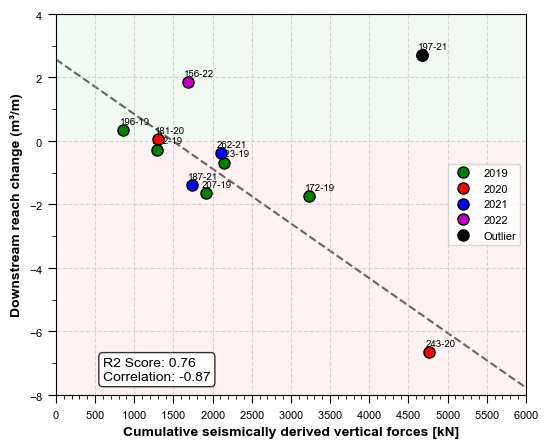

In [29]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))

x_2019, y_2019 = df1[df1.Year == 2019]['CFS'].values, df1[df1.Year == 2019]['Erosion2'].values
x_2020, y_2020 = df1[df1.Year == 2020]['CFS'].values, df1[df1.Year == 2020]['Erosion2'].values
x_2021, y_2021 = df1[df1.Year == 2021].iloc[[1, 2, 4]]['CFS'].values, df1[df1.Year == 2021].iloc[[1, 2, 4]]['Erosion2'].values
x_2022, y_2022 = df1[df1.Year == 2022]['CFS'].values, df1[df1.Year == 2022]['Erosion2'].values

ax.errorbar(
    x=x_2019,
    y=y_2019,
    xerr=None,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="g",
    marker="o",
    markersize=8,
    label=f"2019",
)
ax.errorbar(
    x=x_2020,
    y=y_2020,
    xerr=None,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="r",
    marker="o",
    markersize=8,
    label=f"2020",
)
ax.errorbar(
    x=x_2021,
    y=y_2021,
    xerr=None,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="b",
    marker="o",
    markersize=8,
    label=f"2021",
)
ax.errorbar(
    x=x_2022,
    y=y_2022,
    xerr=None,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="m",
    marker="o",
    markersize=8,
    label=f"2022",
)

labs = np.concatenate([
    np.array(julday_list_2019),
    np.array(julday_list_2020_12)[-2:],
    np.array(julday_list_2021_12)[[2,4,5]],
    np.array(julday_list_2022_12)[0:1]
])
x = np.concatenate([
    x_2019,
    x_2020, x_2021, x_2022
])
y = np.concatenate([
    y_2019, 
    y_2020, y_2021, y_2022
])

# outlier
# ax.plot(diff_list_2019[2], df1[df1.Year == 2019]['Erosion2'].iloc[2], "ko")
# ax.plot(diff_list_2021[4], df1[df1.Year == 2021].iloc[2]['Erosion2'], "ko")
ax.errorbar(
    x=x_2021[1],
    y=y_2021[1],
    xerr=None,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="k",
    marker="o",
    markersize=8,
    label=f"Outlier",
)

for label, x_val, y_val in zip(julday_list_2019, x_2019, y_2019):
    ax.text(x_val-50, y_val+0.2, label, zorder=2)
for label, x_val, y_val in zip(julday_list_2020_12[-2:], x_2020, y_2020):
    ax.text(x_val-50, y_val+0.2, label, zorder=2)
for label, x_val, y_val in zip(np.array(julday_list_2021_12)[[2,4,5]], x_2021, y_2021):
    ax.text(x_val-50, y_val+0.2, label, zorder=2)
for label, x_val, y_val in zip(julday_list_2022_12, x_2022, y_2022):
    ax.text(x_val-50, y_val+0.2, label, zorder=2)
edit_ax(ax, 2)
ax.set_ylim(-8, 4)
ax.set_xlim(0, 6000)

sel_x, sel_y = x[[0,1,2,3,4,5,6,7,9,10]], y[[0,1,2,3,4,5,6,7,9,10]]
corr, _ = stats.pearsonr(sel_x, sel_y)
r2 = corr ** 2
info_text = f"R2 Score: {r2:.2f}\nCorrelation: {corr:.2f}"
ax.text(0.1, 0.1, info_text, transform=ax.transAxes, fontsize=10,
    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

target_slope, target_intercept, _, _, _ = linregress(sel_x, sel_y)
plot_x = np.linspace(0, 8000, 50)
ax.plot(plot_x, target_slope * plot_x + target_intercept, linestyle="--", color="k", alpha=0.6, zorder=0)

ax.legend(loc="best", fontsize=8)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlabel("Cumulative seismically derived vertical forces [kN]", fontsize=10)
fig.tight_layout()

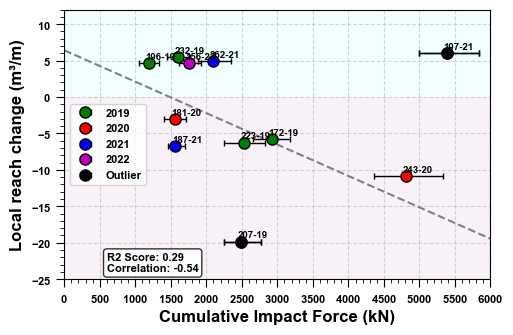

In [221]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))

x_2019, y_2019 = np.array(diff_list_2019), df1[df1.Year == 2019]['Erosion1'].values
x_2020, y_2020 = diff_list_2020[-2:], df1[df1.Year == 2020]['Erosion1'].values
x_2021, y_2021 = diff_list_2021[[2, 4, 5]], df1[df1.Year == 2021].iloc[[1, 2, 4]]['Erosion1'].values
x_2022, y_2022 = diff_list_2022[0:1], df1[df1.Year == 2022]['Erosion1'].values

ax.errorbar(
    x=diff_2019[:,0],
    y=y_2019,
    xerr=diff_2019[:,1:3].T,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="g",
    marker="o",
    markersize=8,
    label=f"2019",
)
ax.errorbar(
    x=diff_2020[-2:,0],
    y=y_2020,
    xerr=diff_2020[-2:,1:3].T,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="r",
    marker="o",
    markersize=8,
    label=f"2020",
)
ax.errorbar(
    x=diff_2021[[2,4,5],0],
    y=y_2021,
    xerr=diff_2021[[2,4,5],1:3].T,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="b",
    marker="o",
    markersize=8,
    label=f"2021",
)
ax.errorbar(
    x=diff_2022[:1,0],
    y=y_2022,
    xerr=diff_2022[:1,1:3].T,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="m",
    marker="o",
    markersize=8,
    label=f"2022",
)

labs = np.concatenate([
    np.array(julday_list_2019),
    np.array(julday_list_2020)[-2:],
    np.array(julday_list_2021)[[2,4,5]],
    np.array(julday_list_2022)[0:1]
])
x = np.concatenate([
    x_2019,
    x_2020, x_2021, x_2022
])
y = np.concatenate([
    y_2019, 
    y_2020, y_2021, y_2022
])

# outlier
# ax.plot(diff_list_2019[2], df1[df1.Year == 2019]['Erosion2'].iloc[2], "ko")
ax.errorbar(
    x=diff_2019[2,0],
    y=y_2019[2],
    xerr=diff_2019[2:3,1:3].T,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="k",
    marker="o",
    markersize=8,
)
ax.errorbar(
    x=diff_2021[4,0],
    y=y_2021[1],
    xerr=diff_2021[4:5,1:3].T,
    yerr=None,
    capsize=2,
    ls='none',
    elinewidth=1,
    color="k",
    mfc="k",
    marker="o",
    markersize=8,
    label=f"Outlier",
)

for label, x_val, y_val in zip(julday_list_2019, x_2019, y_2019):
    ax.text(x_val-50, y_val+0.5, label)
for label, x_val, y_val in zip(julday_list_2020[-2:], x_2020, y_2020):
    ax.text(x_val-50, y_val+0.5, label)
for label, x_val, y_val in zip(np.array(julday_list_2021)[[2,4,5]], x_2021, y_2021):
    ax.text(x_val-50, y_val+0.5, label)
for label, x_val, y_val in zip(julday_list_2022, x_2022, y_2022):
    ax.text(x_val-50, y_val+0.5, label)
edit_ax(ax, 1)
ax.set_xlim(0, 6000)

sel_x, sel_y = x[[0,1,2,3,4,5,6,7,9,10]], y[[0,1,2,3,4,5,6,7,9,10]]
corr, _ = stats.pearsonr(sel_x, sel_y)
r2 = corr ** 2
info_text = f"R2 Score: {r2:.2f}\nCorrelation: {corr:.2f}"
ax.text(0.1, 0.1, info_text, transform=ax.transAxes, fontsize=8,
    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

target_slope, target_intercept, _, _, _ = linregress(sel_x, sel_y)
plot_x = np.linspace(0, 8000, 50)
ax.plot(plot_x, target_slope * plot_x + target_intercept, linestyle="--", color="grey", alpha=1)

ax.legend(loc="best", fontsize=8)
ax.grid(True, linestyle="--", alpha=0.5)